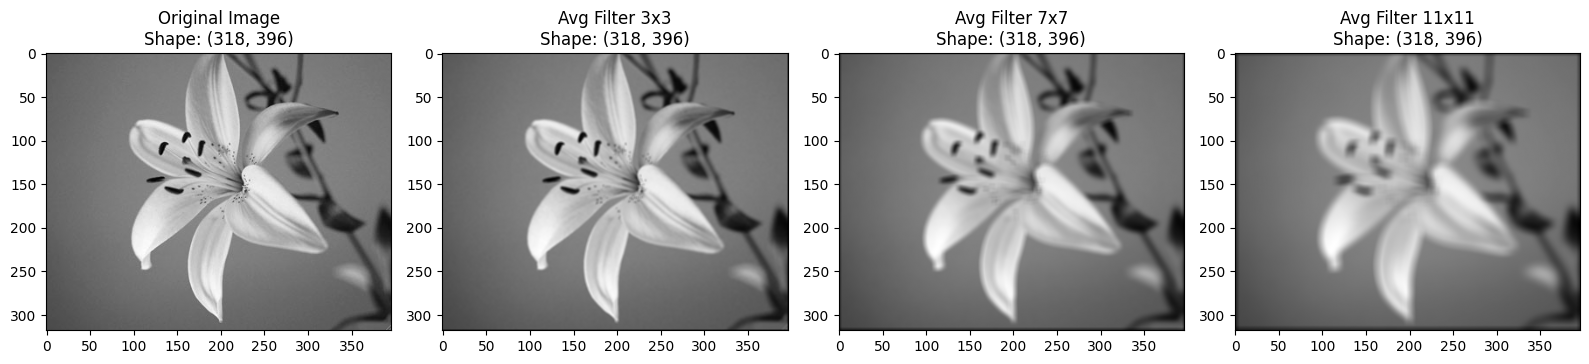

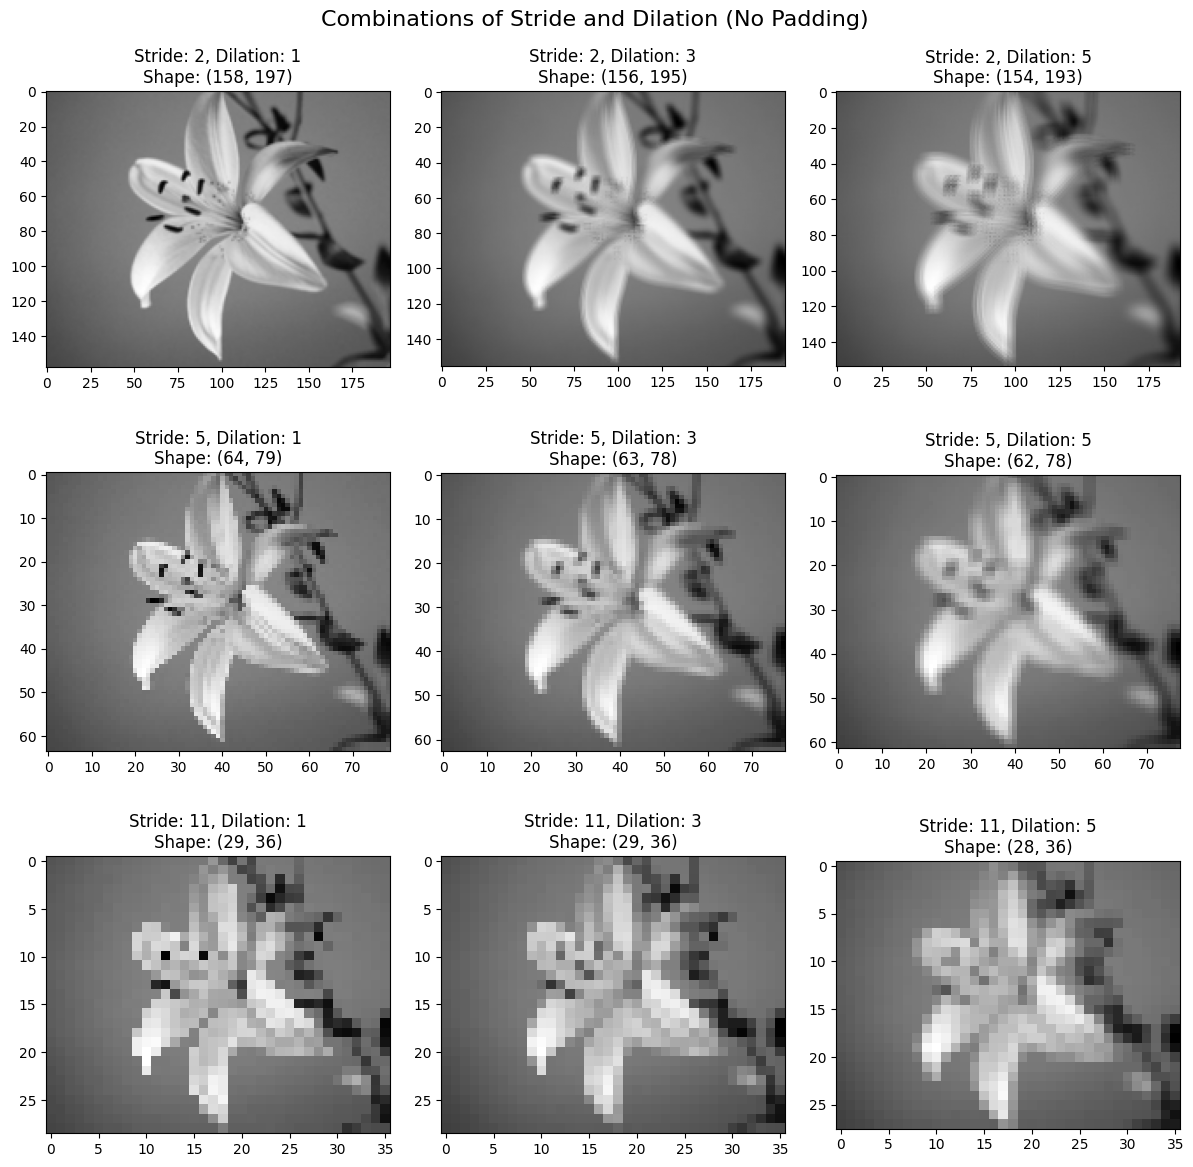

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tools 

img_gray = cv2.imread('flower.png', cv2.IMREAD_GRAYSCALE)
filter_sizes = [3, 7, 11]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title("Original Image\nShape: " + str(img_gray.shape))

for i, size in enumerate(filter_sizes):
    kernel = np.ones((size, size)) / (size ** 2)
    
    pad = size // 2
    
    filtered_img = tools.Conv2D(img_gray, kernel, stride=(1, 1), dilation=(1, 1), padding=(pad, pad))
    
    axes[i+1].imshow(filtered_img, cmap='gray')
    axes[i+1].set_title(f"Avg Filter {size}x{size}\nShape: {filtered_img.shape}")

plt.tight_layout()
plt.show()


strides = [2, 5, 11]
dilations = [1, 3, 5]
kernel_3x3 = np.ones((3, 3)) / 9 

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle("Combinations of Stride and Dilation (No Padding)", fontsize=16)

for i, s in enumerate(strides):
    for j, d in enumerate(dilations):
        try:
            res = tools.Conv2D(img_gray, kernel_3x3, stride=(s, s), dilation=(d, d), padding=(0, 0))
            axes[i, j].imshow(res, cmap='gray')
            axes[i, j].set_title(f"Stride: {s}, Dilation: {d}\nShape: {res.shape}")
        except AssertionError as e:
            axes[i, j].set_title(f"Stride: {s}, Dilation: {d}\nError: Dim < 0")
            axes[i, j].axis('off')

plt.tight_layout()
plt.show()

Testing Automated Analysis on Grayscale:


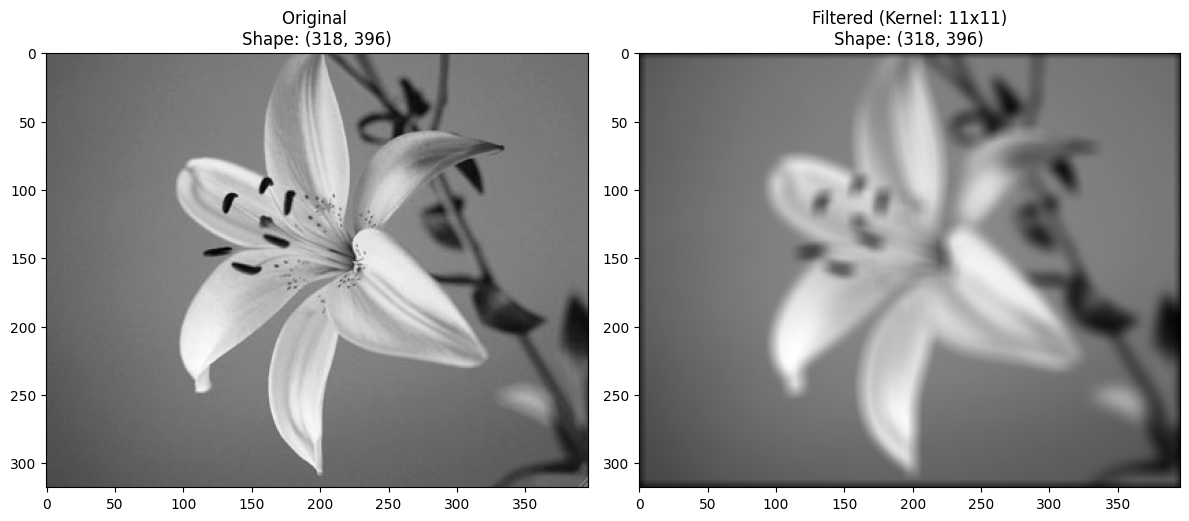

In [3]:
def get_averaging_filter(size=3, **kwargs):
    return np.ones((size, size)) / (size ** 2)

def filter_analysis(img, filter_func, **kwargs):
    
    kernel = filter_func(**kwargs)
    
    is_colored = len(img.shape) == 3
    cmap = None if is_colored else 'gray'
    
    if is_colored:
        filtred_im = tools.apply_filter_to_image(img, kernel)
    else:
       
        pad_x, pad_y = kernel.shape[0] // 2, kernel.shape[1] // 2
        filtred_im = tools.Conv2D(img, kernel, padding=(pad_x, pad_y))
    
    # 4. Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    
    ax[0].imshow(img, cmap=cmap)
    ax[0].set_title(f"Original \nShape: {img.shape}")
    
    ax[1].imshow(filtred_im, cmap=cmap)
    ax[1].set_title(f"Filtered (Kernel: {kernel.shape[0]}x{kernel.shape[1]})\nShape: {filtred_im.shape}")
    
    plt.tight_layout()
    plt.show()
    
    return fig

print("Testing Automated Analysis on Grayscale:")
_ = filter_analysis(img_gray, get_averaging_filter, size=11)

Testing Automated Analysis on Color Image (Averaging Filter):


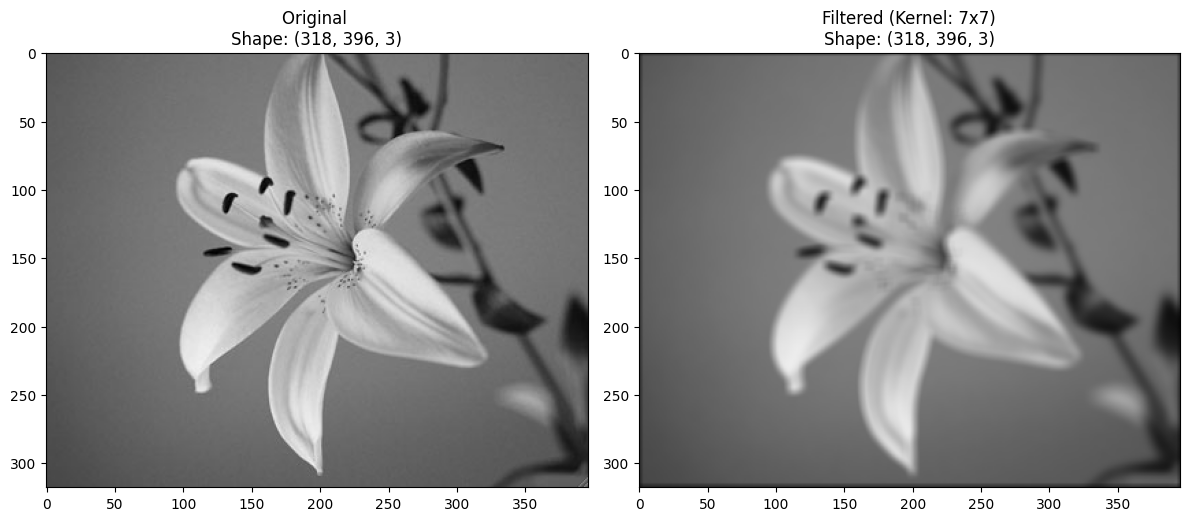

Testing Automated Analysis on Color Image (Gaussian Filter):


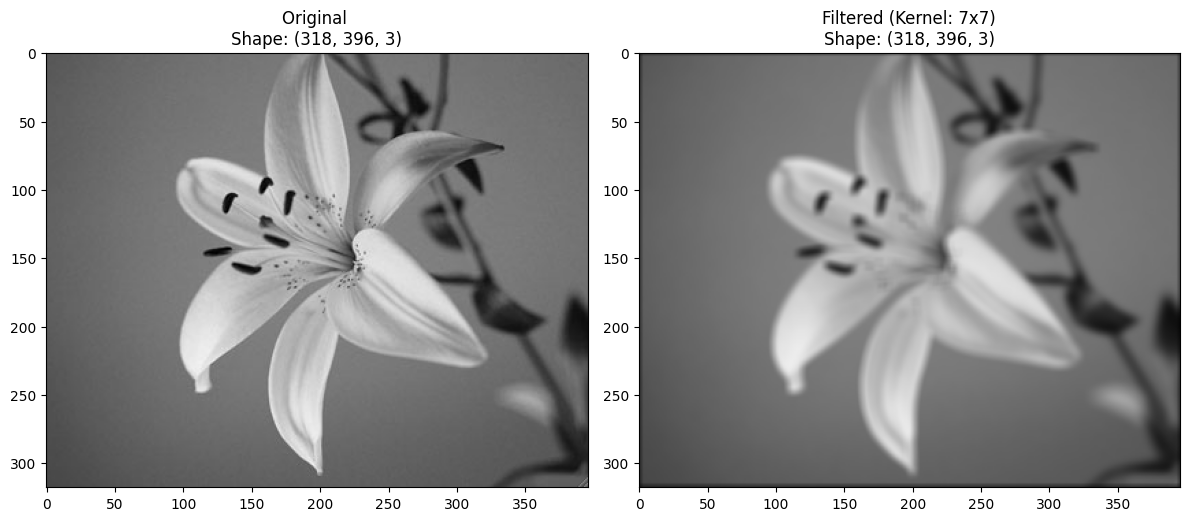

In [4]:
img_color = cv2.imread('flower.png', cv2.IMREAD_COLOR)
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

print("Testing Automated Analysis on Color Image (Averaging Filter):")
_ = filter_analysis(img_color, get_averaging_filter, size=7)

print("Testing Automated Analysis on Color Image (Gaussian Filter):")
_ = filter_analysis(img_color, tools.gaussian_mask, size=7, sigma=1.0)